# Open-System Degradation of a Sideband Swap


This notebook rewrites `examples/open_system_sideband_degradation.py` as a tutorial on realism. We compare an ideal `gf` sideband swap against the same pulse in the presence of transmon relaxation, dephasing, and cavity loss.

The physical message is simple but important: a pulse that looks nearly perfect in closed-system simulation can lose fidelity once realistic dissipation is added, even when the control waveform itself is unchanged.


## Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from tutorials.workflow_tutorial_support import configure_notebook_style

configure_notebook_style()

from cqed_sim import (
    DispersiveTransmonCavityModel,
    FrameSpec,
    NoiseSpec,
    SequenceCompiler,
    SidebandDriveSpec,
    SimulationConfig,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    simulate_sequence,
)
from tutorials.tutorial_support import GHz, MHz, ns


## Physics / model definition


In [2]:
g_sb = MHz(8.0)
scale = g_sb / 0.3
duration_s = np.pi / (2.0 * g_sb)

model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.0),
    alpha=MHz(-220.0),
    chi=MHz(-0.8),
    kerr=0.0,
    n_cav=4,
    n_tr=3,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)
initial_state = model.basis_state(2, 0)
target_state = model.basis_state(0, 1)

noise = NoiseSpec(
    transmon_t1=(120.0 / scale, 35.0 / scale),
    tphi=90.0 / scale,
    kappa=0.02 * scale,
)


## Pulse / sequence construction


In [3]:
omega_sb = model.sideband_transition_frequency(
    cavity_level=0,
    lower_level=0,
    upper_level=2,
    sideband="red",
    frame=frame,
)
pulses, drive_ops, pulse_meta = build_sideband_pulse(
    SidebandDriveSpec(mode="storage", lower_level=0, upper_level=2, sideband="red"),
    duration_s=duration_s,
    amplitude_rad_s=g_sb,
    channel="sb",
    carrier=carrier_for_transition_frequency(omega_sb),
    label="gf_swap",
)
compiled = SequenceCompiler(dt=duration_s / 250.0).compile(pulses, t_end=duration_s)
print("Noise parameters:", noise)


Noise parameters: NoiseSpec(t1=None, transmon_t1=(7.16197243913529e-07, 2.0889086280811265e-07), tphi=5.371479329351467e-07, tphi_storage=None, tphi_readout=None, kappa=3351032.163829113, nth=0.0, kappa_storage=None, kappa_readout=None, nth_storage=None, nth_readout=None)


## Simulation


In [4]:
ideal = simulate_sequence(
    model,
    compiled,
    initial_state,
    drive_ops,
    config=SimulationConfig(frame=frame, store_states=True),
)
open_system = simulate_sequence(
    model,
    compiled,
    initial_state,
    drive_ops,
    config=SimulationConfig(frame=frame, store_states=True),
    noise=noise,
)

target_projector = target_state.proj()

def projector_population(state: qt.Qobj) -> float:
    if state.isoper:
        return float(np.real((target_projector * state).tr()))
    return float(abs(target_state.overlap(state)) ** 2)

ideal_target_population = np.asarray([projector_population(state) for state in ideal.states], dtype=float)
open_target_population = np.asarray([projector_population(state) for state in open_system.states], dtype=float)

print("Ideal final target population:", float(ideal_target_population[-1]))
print("Open-system final target population:", float(open_target_population[-1]))


Ideal final target population: 0.9999954470557013
Open-system final target population: 0.8680333011542449


## Analysis / visualization


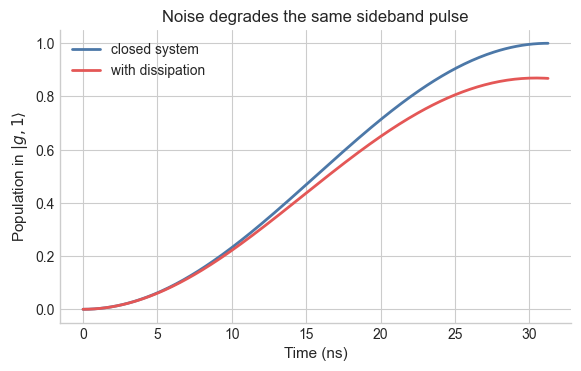

In [5]:
times_ns = np.asarray(compiled.tlist, dtype=float) / ns

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(times_ns, ideal_target_population, label="closed system", lw=2.0, color="#4C78A8")
ax.plot(times_ns, open_target_population, label="with dissipation", lw=2.0, color="#E45756")
ax.set_xlabel("Time (ns)")
ax.set_ylabel(r"Population in $|g,1\rangle$")
ax.set_title("Noise degrades the same sideband pulse")
ax.legend(loc="best")
plt.show()


## Interpretation


Both simulations use the same control pulse. The only difference is the Lindblad noise model, and that difference is enough to reduce the final transfer probability noticeably.

For realistic protocol design, it is therefore not enough to report the coherent unitary result alone. You need to know how far the hardware coherence times sit above the control time scale.


## Variations / exercises


- Increase or decrease the sideband rate to see how faster control trades against rotating-wave accuracy.
- Sweep `transmon_t1` or `kappa` to identify the dominant error channel.
- Compare the open-system result with the sequential-reset notebook, where dissipation is part of the protocol rather than an unwanted error.
